# Run 5 — Multi-Domain Joint Training: One Model for Color (Kaggle/HRIPCB) + Binary (DeepPCB)

**Goal:** train a single YOLOv11n that performs well on BOTH the Kaggle PCB dataset (color) and
DeepPCB (binarized), establishing the **joint-training row** of the cross-dataset benchmark.

Both single-domain baselines scored **0.000** on the opposite modality. This notebook closes that gap with:
1. **Unified label space** — DeepPCB trainval converted directly into the Run2 class-index order.
2. **Domain balancing** — DeepPCB (~1k imgs) is oversampled vs Kaggle (~8.5k) so the binary modality
   isn't drowned out (factor configurable below).
3. **Identical protocol** — same model, imgsz, seed, epochs as Run1/Run2 so rows are comparable.

Run cells top to bottom. Training is the only long cell (~30-60 min on an RTX 3090).

## 1. Environment

In [2]:
import torch
print("PyTorch :", torch.__version__)
print("CUDA    :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU     :", torch.cuda.get_device_name(0))

PyTorch : 2.5.1+cu124
CUDA    : True
GPU     : NVIDIA GeForce RTX 3090


In [3]:
import subprocess, sys
try:
    import ultralytics, kagglehub, yaml
except ImportError:
    subprocess.run([sys.executable,"-m","pip","install","ultralytics","kagglehub","pyyaml","-q"], check=True)
    import ultralytics, kagglehub, yaml
print("ultralytics:", ultralytics.__version__)

ultralytics: 8.4.41


## 2. Configuration

In [4]:
from pathlib import Path
import os

_cwd = Path(os.getcwd()).resolve()
ROOT_ENV = os.environ.get("PCB_PROJECT_ROOT")
if ROOT_ENV:
    PROJECT_ROOT = Path(ROOT_ENV).resolve()
elif _cwd.name == "experiments":
    PROJECT_ROOT = _cwd.parent
elif (_cwd / "experiments").exists():
    PROJECT_ROOT = _cwd
else:
    PROJECT_ROOT = _cwd

SEED, IMG_SIZE, BATCH, DEVICE = 42, 640, 16, 0      # DEVICE='cpu' if no GPU
EPOCHS          = 200                           # protocol-matched to Run1/Run2
DOMAIN_BALANCE  = 4                                 # DeepPCB oversample factor (1 = off)
EXP_NAME        = "exp_006_yolov11n_joint_kaggle_deeppcb_cleanval"

# Unified class space == Run2 training order (DeepPCB conversions already use it)
NAMES = ['mouse_bite','spur','missing_hole','short','open_circuit','spurious_copper']

# DeepPCB raw type (1-6) -> unified index
DEEPPCB_TO_UNIFIED = {1:4, 2:3, 3:0, 4:1, 5:5, 6:2}
# 1=open->open_circuit(4) 2=short(3) 3=mousebite(0) 4=spur(1) 5=copper->spurious(5) 6=pin-hole->missing_hole(2)

DEEPPCB_DIR  = PROJECT_ROOT / "DeepPCB"            # cloned by run3 notebook
DEEPPCB_YOLO = PROJECT_ROOT / "deeppcb_yolo"        # test split already converted by run3
MERGED       = PROJECT_ROOT / "joint_dataset"
RESULTS_DIR  = PROJECT_ROOT / "results"; RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("DeepPCB repo present  :", DEEPPCB_DIR.exists())
print("DeepPCB test converted:", (DEEPPCB_YOLO/'test'/'images').exists())

Project root: /home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection
DeepPCB repo present  : True
DeepPCB test converted: True


## 3. Locate Kaggle dataset (color domain)

In [5]:
import yaml as _yaml
kaggle_root = kagglehub.dataset_download("norbertelter/pcb-defect-dataset")
KAG_DIR = Path(kaggle_root) / "pcb-defect-dataset"
assert (KAG_DIR/"train"/"images").exists(), f"Kaggle train images missing at {KAG_DIR}"

kag_names_raw = _yaml.safe_load((KAG_DIR/"data.yaml").read_text())["names"]
kag_names = [kag_names_raw[i] for i in range(6)] if isinstance(kag_names_raw,dict) else list(kag_names_raw)
assert kag_names == NAMES, f"Kaggle class order {kag_names} != unified {NAMES}"
print("Kaggle class order matches unified space ✔")
for sp in ["train","valid","val","test"]:
    d = KAG_DIR/sp/"images"
    if d.exists(): print(f"  {sp:6s}: {len(list(d.glob('*')))} images")
KAG_VAL = "valid" if (KAG_DIR/"valid"/"images").exists() else "val"

100%|██████████| 1.10G/1.10G [01:29<00:00, 13.2MB/s]

Extracting files...


Kaggle class order matches unified space ✔
  train : 8534 images
  val   : 1066 images
  test  : 1068 images


## 4. Convert DeepPCB **trainval** split to YOLO (unified space)

run3 only converted the test split; joint training needs the train side too.

In [6]:
from PIL import Image
import shutil

PCBDATA = DEEPPCB_DIR / "PCBData"
assert PCBDATA.exists(), f"DeepPCB not found at {DEEPPCB_DIR} — run run3 notebook first (it clones the repo)."

tv_list = next(iter(DEEPPCB_DIR.rglob("trainval.txt")), None)
assert tv_list is not None, "trainval.txt not found in DeepPCB."
print("Using:", tv_list.relative_to(DEEPPCB_DIR))

def resolve(rel): return PCBDATA / rel

def convert_split(list_file, out_split):
    img_out = DEEPPCB_YOLO/out_split/"images"; img_out.mkdir(parents=True, exist_ok=True)
    lbl_out = DEEPPCB_YOLO/out_split/"labels"; lbl_out.mkdir(parents=True, exist_ok=True)
    n_img=n_box=skipped=0
    for line in list_file.read_text().splitlines():
        p = line.strip().split()
        if not p: continue
        img_rel = p[0]
        ann_rel = p[1] if len(p)>1 else img_rel.replace("_test.jpg",".txt")
        img_p, ann_p = resolve(img_rel), resolve(ann_rel)
        if not img_p.exists():
            stem = Path(img_rel).stem
            c = list(PCBDATA.rglob(f"{stem}_test.*")) + list(PCBDATA.rglob(f"{stem}_temp.*")) + list(PCBDATA.rglob(Path(img_rel).name))
            img_p = c[0] if c else img_p
        if not ann_p.exists():
            c=list(PCBDATA.rglob(Path(ann_rel).name)); ann_p=c[0] if c else ann_p
        if not img_p.exists() or not ann_p.exists(): skipped+=1; continue
        with Image.open(img_p) as im: W,H = im.size
        rows=[]
        for raw in ann_p.read_text().splitlines():
            v=raw.split()
            if len(v)<5: continue
            x1,y1,x2,y2,t = float(v[0]),float(v[1]),float(v[2]),float(v[3]),int(float(v[4]))
            if t not in DEEPPCB_TO_UNIFIED: continue
            cx,cy,bw,bh = (x1+x2)/2/W,(y1+y2)/2/H,(x2-x1)/W,(y2-y1)/H
            if bw<=0 or bh<=0: continue
            rows.append(f"{DEEPPCB_TO_UNIFIED[t]} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}"); n_box+=1
        shutil.copy2(img_p, img_out/f"{img_p.stem}.jpg")
        (lbl_out/f"{img_p.stem}.txt").write_text("\n".join(rows))
        n_img+=1
    return n_img, n_box, skipped

if (DEEPPCB_YOLO/"trainval"/"images").exists() and len(list((DEEPPCB_YOLO/"trainval"/"images").glob("*.jpg")))>0:
    print("DeepPCB trainval already converted ✔")
else:
    ni,nb,sk = convert_split(tv_list, "trainval")
    print(f"Converted trainval: {ni} images, {nb} boxes (skipped {sk})")
    assert ni>0 and nb>0

assert (DEEPPCB_YOLO/"test"/"images").exists(), "DeepPCB test split missing — run run3 notebook first."
print("DeepPCB test images:", len(list((DEEPPCB_YOLO/'test'/'images').glob('*.jpg'))))

Using: PCBData/trainval.txt
DeepPCB trainval already converted ✔
DeepPCB test images: 500


## 5. Build the merged, domain-balanced training set

- **train** = Kaggle train + DeepPCB trainval × `DOMAIN_BALANCE` (oversampled via suffixed hardlinks)
- **val**   = Kaggle val + DeepPCB test *(used only for early-signal monitoring; final test metrics are computed per-domain in §8)*

In [7]:
import random as _random

def link_pair(img_src, lbl_src, img_dst, lbl_dst, suffix=""):
    """Hardlink (fallback copy) one image+label pair, optional name suffix for oversampling."""
    img_dst.mkdir(parents=True, exist_ok=True); lbl_dst.mkdir(parents=True, exist_ok=True)
    n=0
    for ip in sorted(img_src.glob("*.[jJpP][pPnN][gG]*")):
        lp = lbl_src/(ip.stem+".txt")
        if not lp.exists(): continue
        di = img_dst/f"{ip.stem}{suffix}{ip.suffix}"
        dl = lbl_dst/f"{ip.stem}{suffix}.txt"
        if not di.exists():
            try: os.link(ip, di)
            except OSError: shutil.copy2(ip, di)
        if not dl.exists():
            try: os.link(lp, dl)
            except OSError: shutil.copy2(lp, dl)
        n+=1
    return n

def link_list(img_list, lbl_src, img_dst, lbl_dst, suffix=""):
    """Same as link_pair but accepts an explicit list of image paths instead of a directory."""
    img_dst.mkdir(parents=True, exist_ok=True); lbl_dst.mkdir(parents=True, exist_ok=True)
    n=0
    for ip in img_list:
        lp = lbl_src/(ip.stem+".txt")
        if not lp.exists(): continue
        di = img_dst/f"{ip.stem}{suffix}{ip.suffix}"
        dl = lbl_dst/f"{ip.stem}{suffix}.txt"
        if not di.exists():
            try: os.link(ip, di)
            except OSError: shutil.copy2(ip, di)
        if not dl.exists():
            try: os.link(lp, dl)
            except OSError: shutil.copy2(lp, dl)
        n+=1
    return n

# Split DeepPCB trainval 90/10 — val slice never seen during checkpoint selection.
# DeepPCB test split is reserved exclusively for final evaluation.
all_dp = sorted((DEEPPCB_YOLO/"trainval"/"images").glob("*.[jJpP][pPnN][gG]*"))
_random.seed(SEED)
_random.shuffle(all_dp)
cut = max(1, int(len(all_dp) * 0.10))
dp_val_imgs = all_dp[:cut]
dp_tr_imgs  = all_dp[cut:]
print(f"DeepPCB trainval split: {len(dp_tr_imgs)} train  /  {len(dp_val_imgs)} val (10% held-out)")

TR_I, TR_L = MERGED/"train"/"images", MERGED/"train"/"labels"
VA_I, VA_L = MERGED/"val"/"images",   MERGED/"val"/"labels"

if TR_I.exists():
    shutil.rmtree(MERGED)   # rebuild cleanly each run

n_kag_tr = link_pair(KAG_DIR/"train"/"images", KAG_DIR/"train"/"labels", TR_I, TR_L)
n_dp_tr  = 0
for k in range(DOMAIN_BALANCE):
    n_dp_tr += link_list(dp_tr_imgs, DEEPPCB_YOLO/"trainval"/"labels", TR_I, TR_L, suffix=f"_d{k}")
n_kag_va = link_pair(KAG_DIR/KAG_VAL/"images", KAG_DIR/KAG_VAL/"labels", VA_I, VA_L)
n_dp_va  = link_list(dp_val_imgs, DEEPPCB_YOLO/"trainval"/"labels", VA_I, VA_L, suffix="_dp")

print(f"train: {n_kag_tr} Kaggle + {n_dp_tr} DeepPCB (x{DOMAIN_BALANCE})  = {n_kag_tr+n_dp_tr}")
print(f"val  : {n_kag_va} Kaggle + {n_dp_va} DeepPCB (10% slice) = {n_kag_va+n_dp_va}")
print("DeepPCB test split untouched — reserved for final eval only.")

import yaml as _yaml
joint_yaml = MERGED/"joint.yaml"
joint_yaml.write_text(_yaml.dump({
    "path": str(MERGED), "train": "train/images", "val": "val/images",
    "names": {i:n for i,n in enumerate(NAMES)},
}, sort_keys=False))
print("\n", joint_yaml.read_text())

DeepPCB trainval split: 900 train  /  100 val (10% held-out)
train: 6370 Kaggle + 3600 DeepPCB (x4)  = 9970
val  : 802 Kaggle + 100 DeepPCB (10% slice) = 902
DeepPCB test split untouched — reserved for final eval only.

 path: /home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection/joint_dataset
train: train/images
val: val/images
names:
  0: mouse_bite
  1: spur
  2: missing_hole
  3: short
  4: open_circuit
  5: spurious_copper



## 6. Train (protocol-matched: YOLOv11n, 200 ep, imgsz 640, seed 42, explicit strong augmentation)

In [ ]:
from ultralytics import YOLO

AUG = dict(   # explicit & strong — also acts as cross-modality regularizer
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.5,
    degrees=10.0, translate=0.10, scale=0.5, shear=2.0,
    flipud=0.5, fliplr=0.5,
    mosaic=1.0, mixup=0.10, copy_paste=0.0,
)

model = YOLO("yolo11n.pt")
results = model.train(
    data=str(joint_yaml), epochs=EPOCHS, imgsz=IMG_SIZE, batch=BATCH, device=DEVICE,
    seed=SEED, deterministic=True,
    project=str(RESULTS_DIR), name=EXP_NAME, exist_ok=True,
    patience=50, **AUG,
)
BEST = RESULTS_DIR/EXP_NAME/"weights"/"best.pt"
print("\nbest.pt:", BEST, BEST.exists())

New https://pypi.org/project/ultralytics/8.4.64 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.41 🚀 Python-3.11.9 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 3090, 24115MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection/joint_dataset/joint.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.5, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train,

## 7. Per-domain test yamls

In [8]:
EVAL_DIR = MERGED/"eval"; EVAL_DIR.mkdir(exist_ok=True)
BEST = RESULTS_DIR/EXP_NAME/"weights"/"best.pt"

kag_test_yaml = EVAL_DIR/"kaggle_test.yaml"
kag_test_yaml.write_text(_yaml.dump({
    "path": str(KAG_DIR), "train":"test/images","val":"test/images","test":"test/images",
    "names": {i:n for i,n in enumerate(NAMES)}}, sort_keys=False))

dp_test_yaml = EVAL_DIR/"deeppcb_test.yaml"
dp_test_yaml.write_text(_yaml.dump({
    "path": str(DEEPPCB_YOLO), "train":"test/images","val":"test/images","test":"test/images",
    "names": {i:n for i,n in enumerate(NAMES)}}, sort_keys=False))

run1_test = PROJECT_ROOT/"cross_tmp"/"run2_on_run1"      # Run1 test already remapped to unified space by run4
run1_yaml = None
if (run1_test/"test"/"images").exists():
    run1_yaml = EVAL_DIR/"run1_test.yaml"
    run1_yaml.write_text(_yaml.dump({
        "path": str(run1_test), "train":"test/images","val":"test/images","test":"test/images",
        "names": {i:n for i,n in enumerate(NAMES)}}, sort_keys=False))
print("eval yamls ready; run1 bonus eval:", run1_yaml is not None)

eval yamls ready; run1 bonus eval: True


## 8. Evaluate the joint model on every test domain

In [10]:
import pandas as pd
from ultralytics import YOLO

joint = YOLO(str(BEST))

def ev(yaml_path, tag):
    r = joint.val(data=str(yaml_path), split="test", imgsz=IMG_SIZE, batch=BATCH, device=DEVICE,
                  project=str(RESULTS_DIR), name=f"{EXP_NAME}_on_{tag}", exist_ok=True,
                  plots=False, verbose=False)
    m50, m = float(r.box.map50), float(r.box.map)
    idx  = list(r.box.ap_class_index)
    ap50 = {int(c):float(a) for c,a in zip(idx, r.box.ap50)}
    pc = pd.DataFrame({"Class":NAMES, "AP@50":[round(ap50.get(i,float('nan')),4) for i in range(6)]})
    print(f"\nJoint -> {tag}:  mAP50={m50:.4f}  mAP50-95={m:.4f}")
    print(pc.to_string(index=False))
    pc.to_csv(RESULTS_DIR/f"{EXP_NAME}_on_{tag}_perclass.csv", index=False)
    return m50, m

j_kag50, j_kag = ev(kag_test_yaml, "kaggle")
j_dp50,  j_dp  = ev(dp_test_yaml,  "deeppcb")
j_r150 = j_r1 = None
if run1_yaml: j_r150, j_r1 = ev(run1_yaml, "run1")

Ultralytics 8.4.41 🚀 Python-3.11.9 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 3090, 24115MiB)
YOLO11n summary (fused): 101 layers, 2,583,322 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5967.1±1116.6 MB/s, size: 111.5 KB)
val: Scanning /home/vector/.cache/kagglehub/datasets/norbertelter/pcb-defect-dataset/versions/2/pcb-defect-dataset/test/labels... 829 images, 239 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1068/1068 2.3Kit/s 0.5s.0s
val: New cache created: /home/vector/.cache/kagglehub/datasets/norbertelter/pcb-defect-dataset/versions/2/pcb-defect-dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 67/67 25.4it/s 2.6s0.1s
                   all       1068       1662      0.761      0.989      0.804       0.48
Speed: 0.2ms preprocess, 1.1ms inference, 0.0ms loss, 0.2ms postprocess per image

Joint -> kaggle:  mAP50=0.8045  mAP50-95=0.4798
          Class  AP@50
  

## 9. Updated benchmark table — single-domain rows vs the joint row

In [11]:
gm = pd.read_csv(RESULTS_DIR/"generalization_matrix.csv")
def cell(tr,te):
    r = gm[(gm["Train"]==tr)&(gm["Test"]==te)]
    return float(r["mAP@50"].iloc[0]) if len(r) else None

rows = [
    {"Train":"Run1 (HRIPCB-local)", "Run1 test":cell("Run1","Run1 test"),
     "Run2 test":cell("Run1","Run2 test"), "DeepPCB test":cell("Run1","DeepPCB test")},
    {"Train":"Run2 (Kaggle)",       "Run1 test":cell("Run2","Run1 test"),
     "Run2 test":cell("Run2","Run2 test"), "DeepPCB test":cell("Run2","DeepPCB test")},
    {"Train":"Joint (Kaggle+DeepPCB)", "Run1 test":j_r150,
     "Run2 test":j_kag50, "DeepPCB test":j_dp50},
]
bench = pd.DataFrame(rows)
bench.to_csv(RESULTS_DIR/"benchmark_with_joint.csv", index=False)
print("====  BENCHMARK (mAP@50)  ====")
print(bench.to_string(index=False))

====  BENCHMARK (mAP@50)  ====
                 Train  Run1 test  Run2 test  DeepPCB test
   Run1 (HRIPCB-local)   0.924400   0.467600      0.000000
         Run2 (Kaggle)   0.825600   0.993100      0.000000
Joint (Kaggle+DeepPCB)   0.847104   0.804488      0.978823


## 10. Heatmap

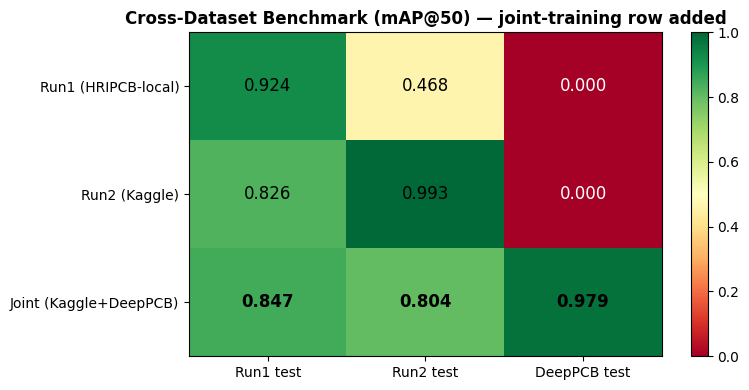

Saved: /home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection/results/benchmark_with_joint_heatmap.png


In [12]:
import matplotlib.pyplot as plt
import numpy as np

cols = ["Run1 test","Run2 test","DeepPCB test"]
arr = np.array([[r[c] if r[c] is not None else np.nan for c in cols] for _,r in bench.iterrows()], dtype=float)

fig, ax = plt.subplots(figsize=(8,4))
im = ax.imshow(arr, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols)
ax.set_yticks(range(len(bench))); ax.set_yticklabels(bench["Train"])
for i in range(arr.shape[0]):
    for j in range(arr.shape[1]):
        v = arr[i,j]
        ax.text(j,i, f"{v:.3f}" if not np.isnan(v) else "N/A", ha="center", va="center",
                fontsize=12, fontweight="bold" if i==2 else "normal",
                color="white" if (not np.isnan(v) and v<0.35) else "black")
plt.colorbar(im, ax=ax)
ax.set_title("Cross-Dataset Benchmark (mAP@50) — joint-training row added", fontweight="bold")
plt.tight_layout()
hp = RESULTS_DIR/"benchmark_with_joint_heatmap.png"
plt.savefig(hp, dpi=150, bbox_inches="tight"); plt.show()
print("Saved:", hp)

## 11. Qualitative: joint model on BOTH modalities

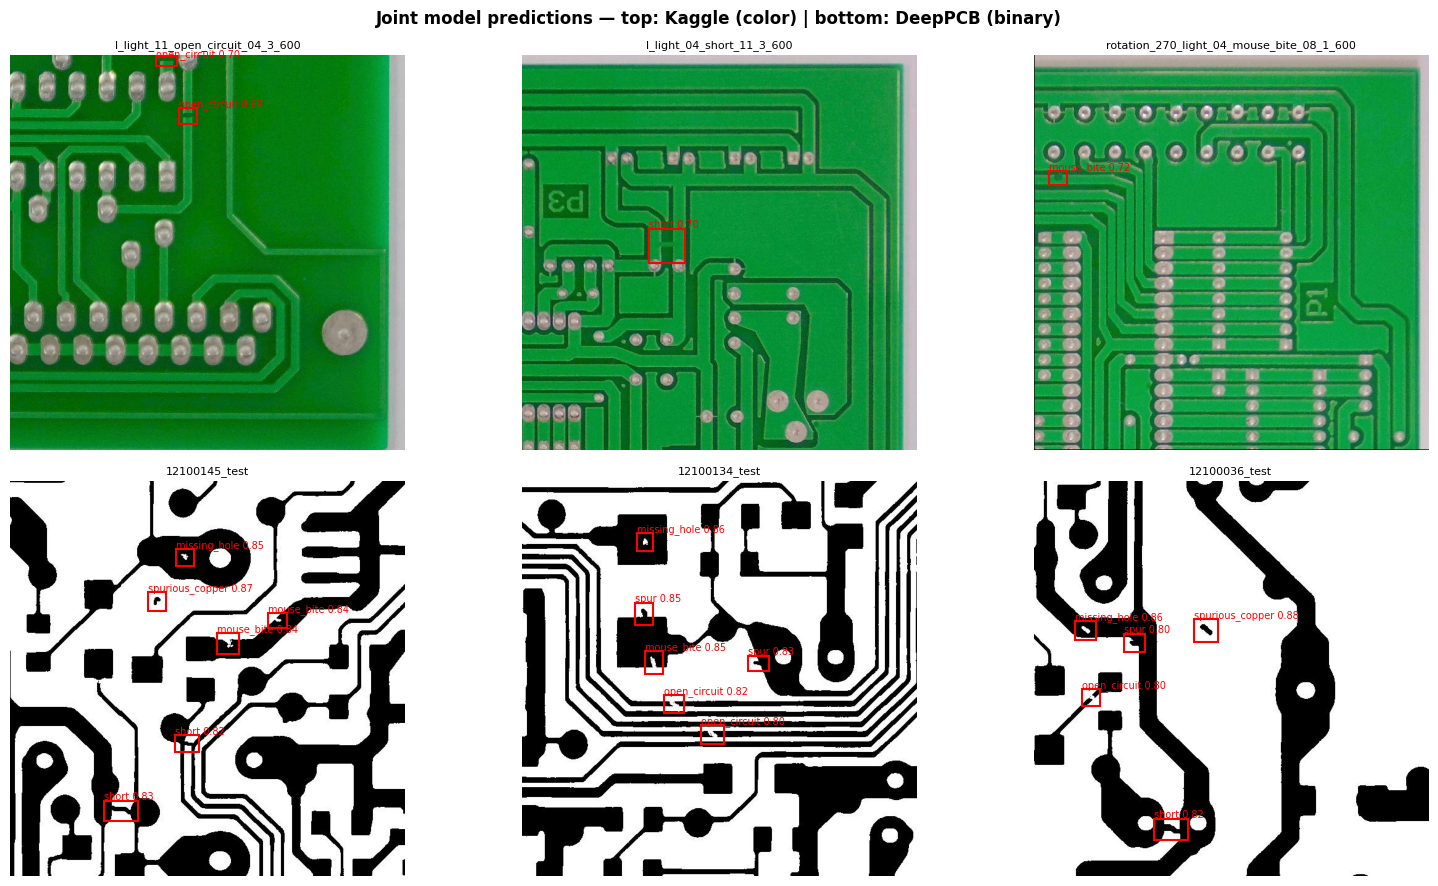

Saved: /home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection/results/exp_006_yolov11n_joint_kaggle_deeppcb_cleanval_qual_both_domains.png


In [13]:
import matplotlib.image as mpimg, random
random.seed(SEED)
kag_imgs = random.sample(sorted((KAG_DIR/"test"/"images").glob("*.jpg")), 3)
dp_imgs  = random.sample(sorted((DEEPPCB_YOLO/"test"/"images").glob("*.jpg")), 3)

fig, axes = plt.subplots(2,3, figsize=(16,9))
for ax, ip in zip(axes.flat, kag_imgs+dp_imgs):
    res = joint.predict(str(ip), imgsz=IMG_SIZE, conf=0.25, verbose=False)[0]
    im = mpimg.imread(str(ip)); ax.imshow(im, cmap="gray")
    for b in res.boxes:
        x1,y1,x2,y2 = b.xyxy[0].tolist()
        ax.add_patch(plt.Rectangle((x1,y1),x2-x1,y2-y1, lw=1.5, edgecolor="red", facecolor="none"))
        ax.text(x1,max(y1-3,0), f"{NAMES[int(b.cls)]} {float(b.conf):.2f}", color="red", fontsize=7)
    ax.set_title(ip.stem, fontsize=8); ax.axis("off")
plt.suptitle("Joint model predictions — top: Kaggle (color) | bottom: DeepPCB (binary)", fontweight="bold")
plt.tight_layout()
qp = RESULTS_DIR/f"{EXP_NAME}_qual_both_domains.png"
plt.savefig(qp, dpi=120); plt.show()
print("Saved:", qp)

## 12. What this establishes

The benchmark now has its three canonical rows:

| Row | Meaning |
|---|---|
| **Run1 / Run2 single-domain** | what the field currently does — collapses cross-modality (0.000) |
| **Joint (multi-domain)** | the achievable upper bound with full access to both domains |
| *(gap between them)* | the headroom that future domain-generalization methods must close |

**Paper claims this supports**
1. Single-source PCB detectors fail catastrophically across imaging modalities.
2. Unified-label joint training recovers both domains with one compact model (YOLOv11n) — no architecture change.
3. The remaining deltas (joint vs each in-domain specialist) quantify the multi-domain interference cost.

**Still to run for the full paper:** the augmentation ablation (Run1 data + Run2-strength aug) to isolate
*why* Run2 transferred better — that's the causal-mechanism section.